# 03-Partitioning & The Shuffle Penalty

In Lesson 02, we observed the Catalyst Optimizer rewrite our declarative Python code into highly efficient physical execution plans.

However, the Optimizer cannot break the laws of physics. In a distributed cluster, data is fractured across dozens of distinct physical machines (Executors). If you execute a query that requires data on Server A to be compared against data on Server B, that data must be physically serialized into byte arrays, pushed through a physical ethernet cable, and deserialized on the receiving end.

This network movement is called **The Shuffle**. It is mathematically the most expensive and dangerous operation in Big Data engineering. A poorly partitioned Shuffle will saturate network bandwidth, trigger OutOfMemory (OOM) killer routines, and crash petabyte-scale pipelines.

Let's boot our cluster to engineer the physics of data locality.

In [1]:
# Required installations: pip install pyspark matplotlib seaborn
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Distributed Network Physics Environment Ready.")

✅ Systems Architecture & Distributed Network Physics Environment Ready.


# 1. The Mathematics of Data Lineage Dependencies

In Spark, a DataFrame is mathematically an RDD (Resilient Distributed Dataset) evaluated over a lineage graph. The edges of this graph represent the flow of data between physical Partitions ($\mathcal{P}$).

There are two strict topological classes of operations:

### 1. Narrow Dependencies ($\mathcal{O}(1)$ Network Cost)

In a Narrow transformation (e.g., `.filter()`, `.map()`, `.withColumn()`), the data required to compute the output partition $\mathcal{P}_{out}$ resides entirely within a single parent partition $\mathcal{P}_{in}$.


$$f(\mathcal{P}_{in}) \rightarrow \mathcal{P}_{out}$$


Because the data already lives in the local RAM of the Executor, no network transfer is required. The execution speed is bounded strictly by the localized CPU clock speed.

### 2. Wide Dependencies ($\mathcal{O}(N \times M)$ Network Cost)

In a Wide transformation (e.g., `.groupBy()`, `.join()`, `.orderBy()`), calculating a single output partition requires data from *multiple* (or all) parent partitions.
If you group by `user_id`, Spark must ensure that all records belonging to `user_id = 42` end up on the exact same Executor. If those records are scattered across 100 partitions, Spark must trigger an **All-to-All Network Shuffle**.


$$\bigcup_{i=1}^{N} \mathcal{P}_i \xrightarrow{\text{TCP/IP Serialization}} \mathcal{P}_{out}$$


This operation halts the CPU, forces data to spill to the physical hard disk (Shuffle Write), and congests the network router (Shuffle Read).

# 2. Architecting the Shuffle Penalty

Let's observe the physical manifestation of a Wide Dependency. We will configure our Spark cluster, generate a distributed dataset, and execute a `groupBy`. We will use `.explain()` to track the exact moment the CPU halts and the Network Shuffle begins.

In [2]:
# --- ⚙️ STEP 1: Booting the Cluster ---
# We explicitly set the default shuffle partitions to a visible number (e.g., 8)
spark = SparkSession.builder \
    .appName("Shuffle_Physics") \
    .master("local[4]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

# --- 📦 STEP 2: Generating Distributed Partitions ---
print("--- 🚀 Generating Distributed DataFrame ---")
# Generate 1 million rows of simulated transactional data
df = spark.range(0, 1000000).withColumn("category", (F.col("id") % 5).cast("string"))

print(f"Initial physical partitions in RAM: {df.rdd.getNumPartitions()}")

# --- 🟢 STEP 3: Executing a Narrow Transformation ---
print("\n--- 🟢 Analyzing Narrow Dependency (No Network I/O) ---")
narrow_df = df.filter(F.col("category") == "3")
narrow_df.explain()

# --- 🛑 STEP 4: Executing a Wide Transformation (The Shuffle) ---
print("\n--- 🛑 Analyzing Wide Dependency (Network Shuffle Triggered) ---")
wide_df = df.groupBy("category").count()
wide_df.explain()

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the execution plans.")
print("In the Narrow Dependency (Filter), you see 'Filter' layered directly on top of 'Range'. There is no network movement. The executor CPU simply skips rows in its local RAM block.")
print("In the Wide Dependency (GroupBy), a massive new node appears: 'Exchange hashpartitioning(category, 8)'. The word 'Exchange' is Spark's physical term for a Network Shuffle. It means the JVMs have halted compute, hashed the 'category' strings, and are actively firing byte arrays across the network to realign the data into 8 new physical partitions.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/25 15:02:21 WARN Utils: Your hostname, Muhammet, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/25 15:02:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 15:02:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/25 15:02:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/06/25 15:02:23 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


--- 🚀 Generating Distributed DataFrame ---
Initial physical partitions in RAM: 4

--- 🟢 Analyzing Narrow Dependency (No Network I/O) ---
== Physical Plan ==
*(1) Project [id#0L, cast((id#0L % 5) as string) AS category#1]
+- *(1) Filter (cast((id#0L % 5) as string) = 3)
   +- *(1) Range (0, 1000000, step=1, splits=4)



--- 🛑 Analyzing Wide Dependency (Network Shuffle Triggered) ---
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[category#1], functions=[count(1)])
   +- Exchange hashpartitioning(category#1, 8), ENSURE_REQUIREMENTS, [plan_id=35]
      +- HashAggregate(keys=[category#1], functions=[partial_count(1)])
         +- Project [cast((id#0L % 5) as string) AS category#1]
            +- Range (0, 1000000, step=1, splits=4)



--- 💡 Engineering Insight ---
Look closely at the execution plans.
In the Narrow Dependency (Filter), you see 'Filter' layered directly on top of 'Range'. There is no network movement. The executor CPU simply skips rows in its l

# 3. Controlling the Physics: Repartition vs. Coalesce

Because Shuffles are catastrophic to pipeline latency, Senior Data Engineers must mathematically control the partition array topology.
When writing files to the Data Lakehouse (e.g., S3/Parquet), writing 10,000 tiny 1MB files will destroy read performance (The "Small File Problem"). We must compress them into 10 large 1GB files before writing.

Spark provides two functions to alter partition counts: `repartition()` and `coalesce()`. They sound identical, but their underlying network physics are exact opposites.

In [3]:
# --- ⚖️ The Physics of Partition Modification ---

print("\n--- 💥 Method A: .repartition(2) ---")
# Repartition mathematically forces a full all-to-all Network Shuffle.
# It distributes data perfectly evenly using Round-Robin hashing.
repartitioned_df = df.repartition(2)
repartitioned_df.explain()
print("Result: Notice the 'Exchange RoundRobinPartitioning(2)' node. A massive, expensive network event was manually triggered.")

print("\n--- 🎯 Method B: .coalesce(2) ---")
# Coalesce mathematically forbids a Network Shuffle.
# It simply merges local partitions residing on the same physical worker node.
coalesced_df = df.coalesce(2)
coalesced_df.explain()
print("Result: Notice there is NO 'Exchange' node. The data was compressed into 2 partitions without ever hitting the network interface card (NIC).")

print("\n--- 💡 The Engineering Rule ---")
print("If you need to decrease partitions before writing to a Data Lake, ALWAYS use .coalesce() to avoid the $\\mathcal{O}(N \\times M)$ network penalty.")
print("If you need to increase partitions to utilize more CPU cores, or if your data is suffering from severe Skew (one executor has 99% of the data), you MUST pay the penalty and use .repartition() to force a hash redistribution.")


--- 💥 Method A: .repartition(2) ---
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Exchange RoundRobinPartitioning(2), REPARTITION_BY_NUM, [plan_id=47]
   +- Project [id#0L, cast((id#0L % 5) as string) AS category#1]
      +- Range (0, 1000000, step=1, splits=4)


Result: Notice the 'Exchange RoundRobinPartitioning(2)' node. A massive, expensive network event was manually triggered.

--- 🎯 Method B: .coalesce(2) ---
== Physical Plan ==
Coalesce 2
+- *(1) Project [id#0L, cast((id#0L % 5) as string) AS category#1]
   +- *(1) Range (0, 1000000, step=1, splits=4)


Result: Notice there is NO 'Exchange' node. The data was compressed into 2 partitions without ever hitting the network interface card (NIC).

--- 💡 The Engineering Rule ---
If you need to decrease partitions before writing to a Data Lake, ALWAYS use .coalesce() to avoid the $\mathcal{O}(N \times M)$ network penalty.
If you need to increase partitions to utilize more CPU cores, or if your data is suffering from sever

# 4. Visualizing the Distributed Shuffle Topology

To truly understand why `coalesce()` is computationally cheap and a `groupBy` / `repartition()` is computationally devastating, we must graph the vector flow of data across the topological boundaries of the Worker Nodes.

/tmp/ipykernel_7332/675727702.py:9: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 0), 6, 7, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--'))
/tmp/ipykernel_7332/675727702.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((7, 0), 6, 7, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--'))
/tmp/ipykernel_7332/675727702.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1, y), 1.5, 0.8, fill=True, color='#3498db', edgecolor='black'))
/tmp/ipykernel_7332/675727702.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4, y), 1.5, 0.8, fill=True, color='#2ecc71', edgecolor='black'))
/tmp/

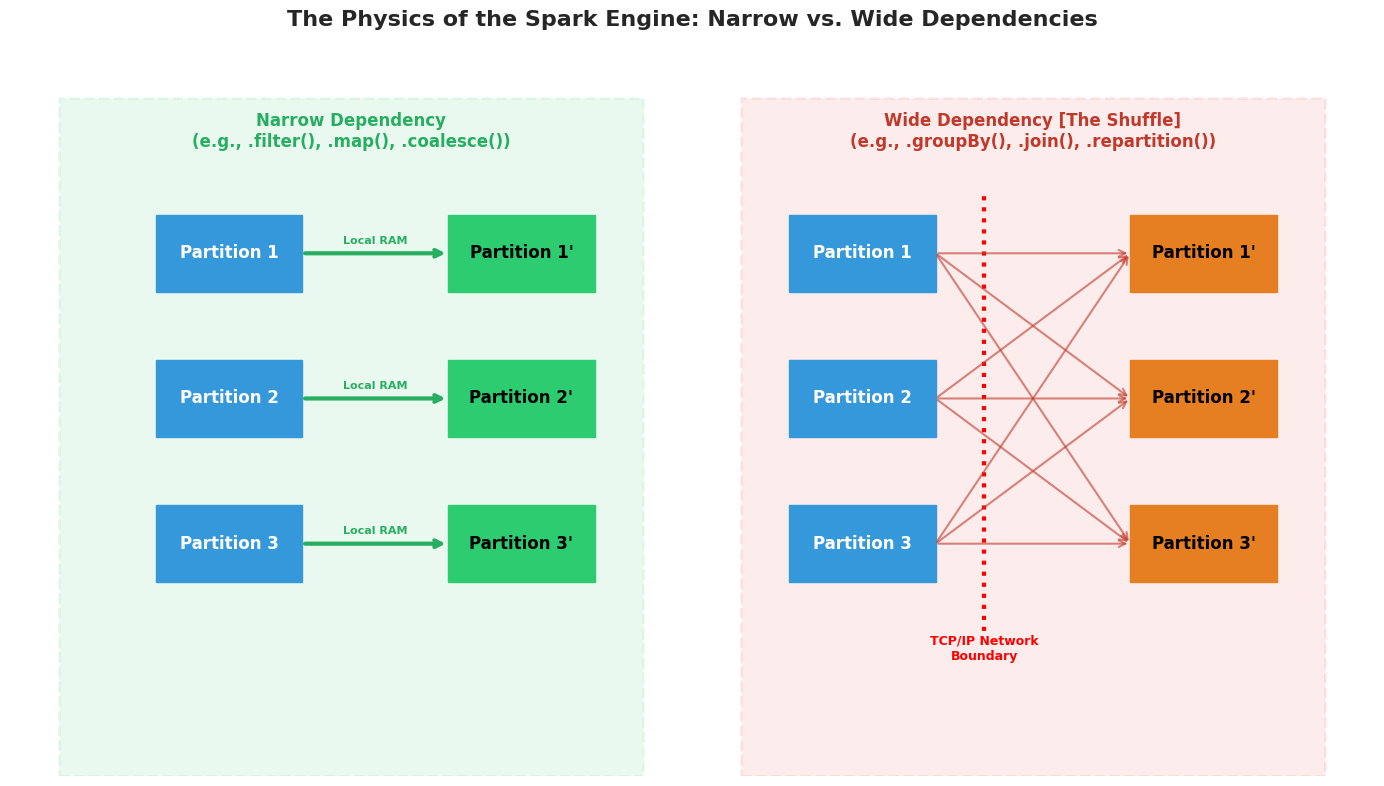

In [4]:
# Visualizing Narrow vs. Wide Network Dependencies
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("The Physics of the Spark Engine: Narrow vs. Wide Dependencies", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Execution Zones
# Left Side: Narrow Dependency
ax.add_patch(patches.Rectangle((0, 0), 6, 7, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--'))
ax.text(3, 6.5, "Narrow Dependency\n(e.g., .filter(), .map(), .coalesce())", ha='center', color='#27ae60', fontweight='bold', fontsize=12)

# Right Side: Wide Dependency (Shuffle)
ax.add_patch(patches.Rectangle((7, 0), 6, 7, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--'))
ax.text(10, 6.5, "Wide Dependency [The Shuffle]\n(e.g., .groupBy(), .join(), .repartition())", ha='center', color='#c0392b', fontweight='bold', fontsize=12)

# --- LEFT: NARROW DEPENDENCY TOPOLOGY ---
# Parent Partitions (Input)
for i, y in enumerate([5.0, 3.5, 2.0]):
    ax.add_patch(patches.Rectangle((1, y), 1.5, 0.8, fill=True, color='#3498db', edgecolor='black'))
    ax.text(1.75, y+0.4, f"Partition {i+1}", ha='center', va='center', color='white', fontweight='bold')

# Child Partitions (Output)
for i, y in enumerate([5.0, 3.5, 2.0]):
    ax.add_patch(patches.Rectangle((4, y), 1.5, 0.8, fill=True, color='#2ecc71', edgecolor='black'))
    ax.text(4.75, y+0.4, f"Partition {i+1}'", ha='center', va='center', color='black', fontweight='bold')

# Data Flow (Straight lines, localized memory, zero cross-talk)
for y in [5.4, 3.9, 2.4]:
    ax.annotate("", xy=(4, y), xytext=(2.5, y), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
    ax.text(3.25, y+0.1, "Local RAM", ha='center', fontsize=8, color="#27ae60", fontweight='bold')

# --- RIGHT: WIDE DEPENDENCY (SHUFFLE) TOPOLOGY ---
# Parent Partitions (Input)
for i, y in enumerate([5.0, 3.5, 2.0]):
    ax.add_patch(patches.Rectangle((7.5, y), 1.5, 0.8, fill=True, color='#3498db', edgecolor='black'))
    ax.text(8.25, y+0.4, f"Partition {i+1}", ha='center', va='center', color='white', fontweight='bold')

# The Network Barrier
ax.plot([9.5, 9.5], [1.5, 6.0], color='red', linestyle=':', linewidth=3)
ax.text(9.5, 1.2, "TCP/IP Network\nBoundary", ha='center', color='red', fontweight='bold', fontsize=9)

# Child Partitions (Output - Shuffled)
for i, y in enumerate([5.0, 3.5, 2.0]):
    ax.add_patch(patches.Rectangle((11, y), 1.5, 0.8, fill=True, color='#e67e22', edgecolor='black'))
    ax.text(11.75, y+0.4, f"Partition {i+1}'", ha='center', va='center', color='black', fontweight='bold')

# Data Flow (All-to-All Matrix Crossing)
y_inputs = [5.4, 3.9, 2.4]
y_outputs = [5.4, 3.9, 2.4]

for yi in y_inputs:
    for yo in y_outputs:
        ax.annotate("", xy=(11, yo), xytext=(9.0, yi), arrowprops=dict(arrowstyle="->", lw=1.5, color="#c0392b", alpha=0.6))

plt.xlim(-0.5, 13.5)
plt.ylim(0, 7.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Narrow vs. Wide dependencies like **Translating Books vs. Organizing a Global Library**:

* **Narrow Dependency (The Factory Floor)**: You hire 10 translators to translate 10 books from English to Spanish. You give 1 book to each translator. They sit at their desks, completely isolated from one another, and translate the book using their own localized brain (RAM). They do not need to talk to each other. The work scales perfectly and finishes in hours.
* **Wide Dependency / The Shuffle (The Global Library Sort)**: You have 10 messy library warehouses scattered across the globe. You tell the 10 librarians: *"I need you to `groupBy('genre')`. Put all the Sci-Fi books in the London warehouse, and all the History books in the Tokyo warehouse."* * The librarians must halt their local work. They must pack millions of books into cardboard boxes (Serialization). They must load them onto physical airplanes (Network Transfer). The airplanes fly across the ocean, land, and the books must be unpacked and sorted (Deserialization).

If a Data Engineer blindly writes `.groupBy()` operations over billions of rows without optimizing their partition topology, they are commanding a fleet of virtual airplanes to continuously take off and land inside their cloud architecture, racking up massive AWS/Azure networking bills and crashing the system.